In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load cleaned datasets

orders = pd.read_csv(
    "../data/cleaned/orders_clean.csv"
)

products = pd.read_csv(
    "../data/cleaned/products_clean.csv"
)

# Load raw tables
items = pd.read_csv(
    "../data/olist_order_items_dataset.csv"
)

payments = pd.read_csv(
    "../data/olist_order_payments_dataset.csv"
)

print("Data Loaded Successfully")

Data Loaded Successfully


In [3]:
# Calculate total revenue

total_revenue = items["price"].sum()

print(
    f"Total Revenue: ${total_revenue:,.2f}"
)

Total Revenue: $13,591,643.70


In [4]:
# Revenue per order

avg_order_value = (
    items["price"].sum()
    / items["order_id"].nunique()
)

print(
    f"Average Order Value: ${avg_order_value:.2f}"
)

Average Order Value: $137.75


In [5]:
# Combine order items and products

revenue_df = items.merge(
    products,
    on="product_id",
    how="left"
)

revenue_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [6]:
# Revenue generated by each category

category_revenue = (
    revenue_df
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

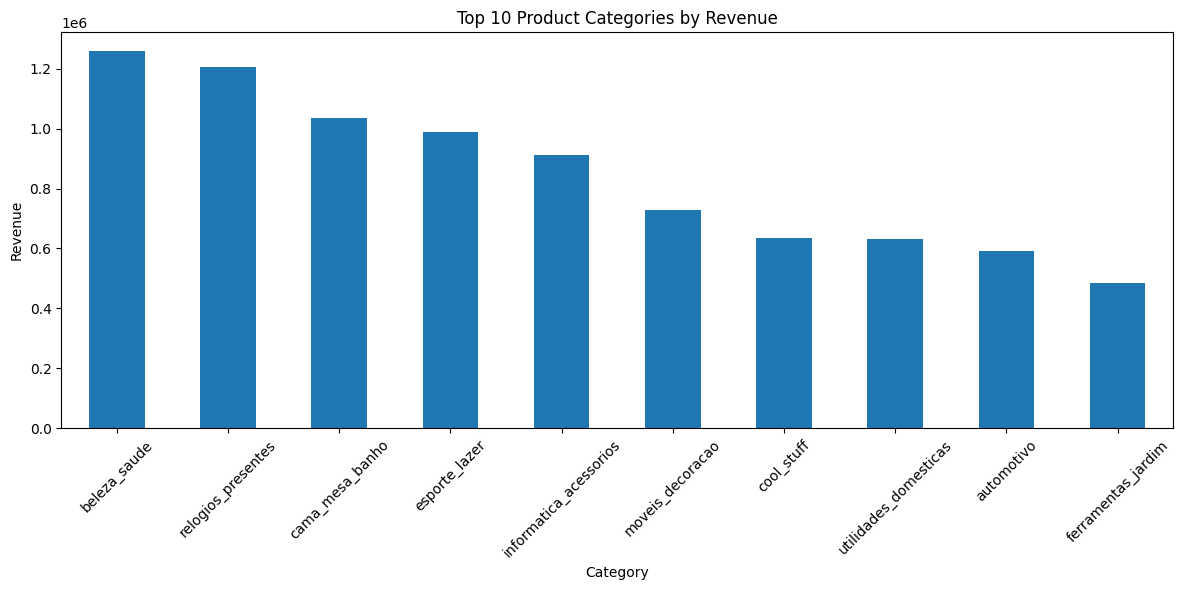

In [8]:
# Top 10 categories chart

# Plot top 10 categories by revenue

top10 = category_revenue.head(10)

plt.figure(figsize=(12,6))

top10.plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Initial Revenue Insights

- Total revenue represents the overall sales generated.
- Average Order Value (AOV) shows spending per order.
- Product categories contribute differently to revenue.
- Top categories should receive higher business focus.

In [9]:
# Combine orders and items

sales_df = orders.merge(
    items,
    on="order_id",
    how="inner"
)

sales_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,month_name,delivery_days,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,July,13.0,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,August,9.0,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,November,13.0,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,February,2.0,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [10]:
# Convert purchase date

sales_df["order_purchase_timestamp"] = pd.to_datetime(
    sales_df["order_purchase_timestamp"]
)

In [11]:
# Create month-year

sales_df["month_year"] = (
    sales_df["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [12]:
# Revenue generated each month

monthly_revenue = (
    sales_df
    .groupby("month_year")["price"]
    .sum()
)

monthly_revenue.head()

month_year
2016-09       267.36
2016-10     49507.66
2016-12        10.90
2017-01    120312.87
2017-02    247303.02
Freq: M, Name: price, dtype: float64

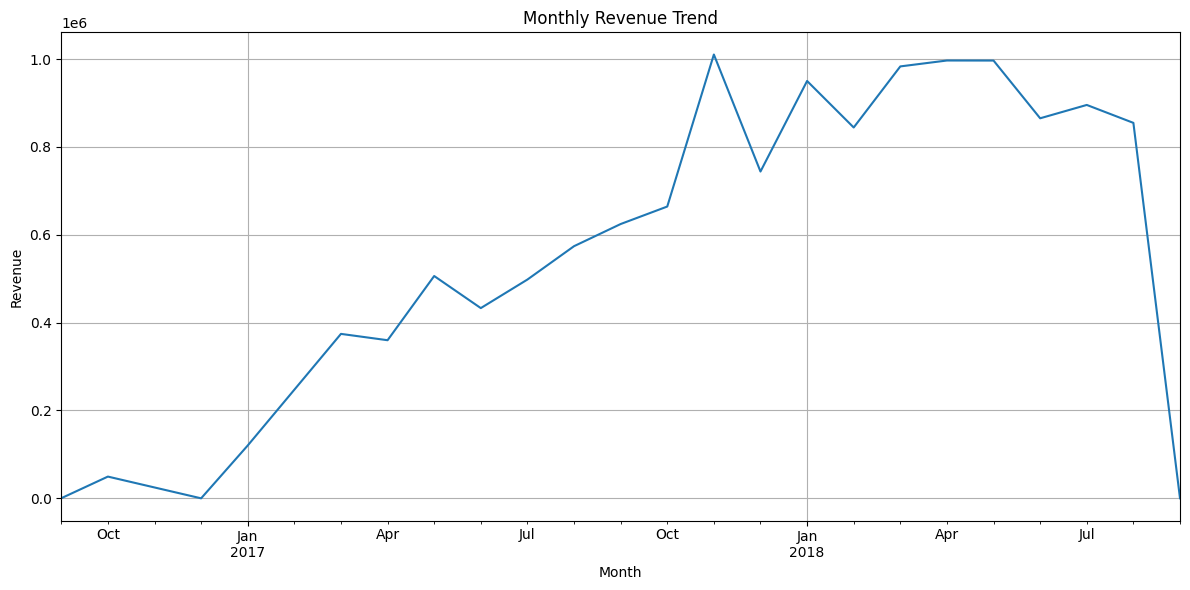

In [13]:
# Plot monthly revenue trend

plt.figure(figsize=(12,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

# Seller Performance Analysis

In [14]:
# Revenue generated by seller

seller_revenue = (
    items
    .groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

seller_revenue.head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

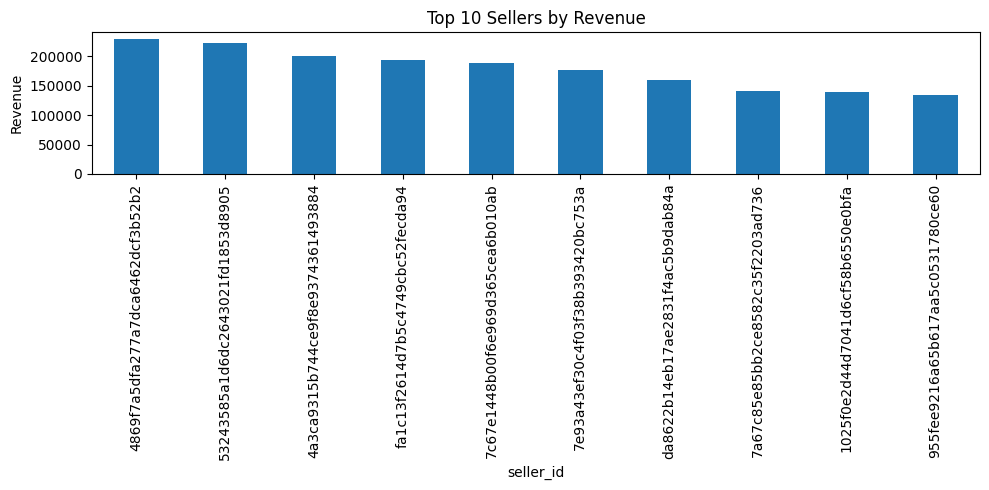

In [15]:
# Top 10 sellers

seller_revenue.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Sellers by Revenue")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

# Revenue Insights

1. Total revenue exceeded $13.5 million.
2. Average customer spending per order was approximately $138.
3. Beauty & Health generated the highest revenue.
4. Revenue is concentrated among a few high-performing categories.
5. Seller contribution varies significantly across the marketplace.